# Token Position Verification

Systematic verification that t_inst and t_post encode harmfulness and refusal
(respectively) across extraction conditions and layers.

### Zhao et al. predictions
- **h_inst** (last content token) should encode **harmfulness** — whether the input is harmful,
  independent of the model's behavioral response
- **h_post** (`<|eot_id|>`) should encode **refusal** — whether the model will refuse,
  independent of actual harmfulness

### Verification plan (fast → slow)
1. **AUROC heatmap** — harmfulness classification AUROC across conditions × layers × positions
2. **Position specificity** — h_inst better for harmfulness, h_post better for refusal?
3. **Silhouette scores** — geometric separability without assuming a direction
4. **Nearest-centroid misbehavior clustering** — where does refused_harmful cluster?
5. **Per-turn × layer heatmaps** — full AUROC sweep across turns and layers (slowest)

### Conditions
- Single-turn baseline (raw JBB goals)
- Full-context trajectory (final turn)
- No-context (final turn)
- Full-context and no-context per turn k

In [1]:
import json as _json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, silhouette_score
from tqdm.auto import tqdm

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODEL     = 'llama'   # model subdirectory under data/

REPR_ROOT = repo_root / 'data' / MODEL / 'representations'
CONV_ROOT = repo_root / 'data' / MODEL / 'conversations'
FIG_DIR   = repo_root / 'figures'

FRAMEWORKS = ['crescendo', 'actorattack', 'xteaming']
SPLITS     = ['harmful', 'benign']

# 8 layers spanning the full range (0-indexed)
# ── Load per-model layer sweep from layer_indices.json ──────────────────────
# After the down-select, saved arrays have shape (N, 8, D). layer_indices.json
# sits next to each (fw_split) directory with the original transformer-layer IDs.

def _load_layer_info(model_root):
    """Walk the representations tree; return the first layer_indices.json found."""
    for sub in ("trajectories", "nocontext", "single_turn"):
        root = model_root / sub
        if not root.exists():
            continue
        for d in root.iterdir():
            fp = d / "layer_indices.json"
            if fp.exists():
                return _json.loads(fp.read_text())
    raise FileNotFoundError(
        f"No layer_indices.json under {model_root} — run scripts/downselect_layers.py"
    )

_LAYER_INFO    = _load_layer_info(REPR_ROOT)
N_SAVED_LAYERS = _LAYER_INFO["n_sweep"]
VERIFY_LAYERS  = list(range(N_SAVED_LAYERS))           # positions into the saved (N, 8, D) arrays
VERIFY_LABELS  = _LAYER_INFO["labels"]                 # e.g. ["L1", "L5", "L9", ...]
N_VERIFY       = N_SAVED_LAYERS
print(f"Saved-layer sweep: {VERIFY_LABELS}")

TRAIN_MAX_ATTEMPT = 16
MAX_K = 10

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})
print(f'Layers to verify: {VERIFY_LABELS}')

Saved-layer sweep: ['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']
Layers to verify: ['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_repr(folder):
    meta   = pd.read_parquet(folder / 'metadata.parquet')
    h_inst = np.load(folder / 'h_inst.npy', mmap_mode='r')
    h_post = np.load(folder / 'h_post_inst.npy', mmap_mode='r')
    assert len(meta) == len(h_inst) == len(h_post)
    return {'meta': meta, 'h_inst': h_inst, 'h_post': h_post}

def add_split(meta):
    meta['data_split'] = np.where(meta['attempt'] <= TRAIN_MAX_ATTEMPT, 'train', 'test')
    return meta

# ── Load all conditions ───────────────────────────────────────────────────────
traj, nc, comp, st = {}, {}, {}, {}

for fw in FRAMEWORKS:
    for split in SPLITS:
        for cond, store, subdir in [('traj', traj, 'trajectories'),
                                     ('nc', nc, 'nocontext'),
                                     ('comp', comp, 'compressed')]:
            folder = REPR_ROOT / subdir / f'{fw}_{split}'
            if not folder.exists():
                continue
            store[(fw, split)] = load_repr(folder)
            add_split(store[(fw, split)]['meta'])
            print(f'  {cond:5s} {fw:14s} {split:8s}  rows={len(store[(fw, split)]["meta"]):6d}')

for split in SPLITS:
    folder = REPR_ROOT / 'single_turn' / split
    if folder.exists():
        st[split] = load_repr(folder)
        print(f'  st    {split:8s}  rows={len(st[split]["meta"]):6d}')

avail_fw = sorted({fw for fw, _ in traj.keys()})
has_nc   = bool(nc)
has_comp = bool(comp)
print(f'\nFrameworks: {avail_fw}')
print(f'No-context: {has_nc}  Compressed: {has_comp}')

  traj  crescendo      harmful   rows= 11985
  nc    crescendo      harmful   rows= 11985
  comp  crescendo      harmful   rows=  1994
  traj  crescendo      benign    rows=  8323
  nc    crescendo      benign    rows=  8323
  comp  crescendo      benign    rows=  1991
  traj  actorattack    harmful   rows= 11982
  nc    actorattack    harmful   rows= 11982
  comp  actorattack    harmful   rows=  1997
  traj  actorattack    benign    rows= 11988
  nc    actorattack    benign    rows= 11998
  comp  actorattack    benign    rows=  1998
  traj  xteaming       harmful   rows=  6461
  nc    xteaming       harmful   rows=  6461
  comp  xteaming       harmful   rows=  1945
  traj  xteaming       benign    rows=  7003
  nc    xteaming       benign    rows=  7003
  comp  xteaming       benign    rows=  1999
  st    harmful   rows=   100
  st    benign    rows=   100

Frameworks: ['actorattack', 'crescendo', 'xteaming']
No-context: True  Compressed: True


In [3]:
# ── Compute v_harmful and v_refusal for each condition ────────────────────────

def paired_direction(h_a, m_a, h_b, m_b, layer):
    """Within-pair direction at a single layer. Returns (4096,) unit vector or None."""
    pairs = sorted(set(m_a['pair_id']) & set(m_b['pair_id']))
    diffs = []
    for pid in pairs:
        idx_a = m_a.index[m_a['pair_id'] == pid].tolist()
        idx_b = m_b.index[m_b['pair_id'] == pid].tolist()
        if not idx_a or not idx_b:
            continue
        mu_a = h_a[idx_a, layer, :].astype(np.float32).mean(axis=0)
        mu_b = h_b[idx_b, layer, :].astype(np.float32).mean(axis=0)
        diffs.append(mu_a - mu_b)
    if not diffs:
        return None
    d = np.stack(diffs).mean(axis=0)
    return d / (np.linalg.norm(d) + 1e-12)

def get_final_turn(data, pos_indices=True):
    """Return positional indices of the final turn per conversation."""
    m = data['meta']
    if 'turn_k' in m.columns:
        return m.groupby('conversation_id')['turn_k'].idxmax().values
    else:
        return np.arange(len(m))

# ── Single-turn v_harmful (all layers at once for speed) ──────────────────────
m_st_h = st['harmful']['meta'].sort_values('pair_id')
m_st_b = st['benign']['meta'].sort_values('pair_id')

v_harmful_st = {}  # layer -> (4096,)
v_refusal_st = {}  # not meaningful for single-turn

for li, ll in zip(VERIFY_LAYERS, VERIFY_LABELS):
    d = (st['harmful']['h_inst'][m_st_h.index, li, :].astype(np.float32) -
         st['benign']['h_inst'][m_st_b.index, li, :].astype(np.float32))
    d_mean = d.mean(axis=0)
    v_harmful_st[li] = d_mean / (np.linalg.norm(d_mean) + 1e-12)

    # h_post version
    dp = (st['harmful']['h_post'][m_st_h.index, li, :].astype(np.float32) -
          st['benign']['h_post'][m_st_b.index, li, :].astype(np.float32))
    dp_mean = dp.mean(axis=0)
    v_harmful_st[('post', li)] = dp_mean / (np.linalg.norm(dp_mean) + 1e-12)

print(f'v_harmful_st computed at {N_VERIFY} layers')

# ── Per-framework v_harmful and v_refusal (final turn, train split) ───────────
v_harmful_traj = {}  # (fw, layer) -> (4096,)
v_refusal_traj = {}  # (fw, layer) -> (4096,)

for fw in tqdm(avail_fw, desc='Directions (traj)'):
    d_h = traj[(fw, 'harmful')]
    d_b = traj[(fw, 'benign')]

    # Final turn, train split
    ft_h = get_final_turn(d_h)
    ft_b = get_final_turn(d_b)
    m_fh = d_h['meta'].loc[ft_h].reset_index(drop=True)
    m_fb = d_b['meta'].loc[ft_b].reset_index(drop=True)
    train_h = m_fh['data_split'] == 'train'
    train_b = m_fb['data_split'] == 'train'

    for h_key, v_store, prefix in [('h_inst', v_harmful_traj, ''),
                                    ('h_post', v_harmful_traj, 'post_')]:
        h_fh = d_h[h_key][ft_h]
        h_fb = d_b[h_key][ft_b]
        for li in VERIFY_LAYERS:
            v = paired_direction(
                h_fh[train_h.values], m_fh[train_h].reset_index(drop=True),
                h_fb[train_b.values], m_fb[train_b].reset_index(drop=True),
                li
            )
            v_store[(fw, prefix + str(li))] = v

    # v_refusal: refused_harmful vs accepted_harmful at h_post (train, final turn)
    acc_mask = (m_fh['attack_success'].values == True) & train_h.values
    ref_mask = (m_fh['attack_success'].values == False) & train_h.values
    if acc_mask.sum() >= 10 and ref_mask.sum() >= 10:
        h_post_fh = d_h['h_post'][ft_h]
        for li in VERIFY_LAYERS:
            mu_ref = h_post_fh[ref_mask, li, :].astype(np.float32).mean(axis=0)
            mu_acc = h_post_fh[acc_mask, li, :].astype(np.float32).mean(axis=0)
            d_ref = mu_ref - mu_acc
            v_refusal_traj[(fw, li)] = d_ref / (np.linalg.norm(d_ref) + 1e-12)

print('Directions computed.')

v_harmful_st computed at 8 layers


Directions (traj): 100%|██████████| 3/3 [00:09<00:00,  3.27s/it]

Directions computed.


## 1. AUROC heatmap — harmfulness classification across conditions × layers

For each condition and layer, project test data onto v_harmful and compute AUROC.
Separate panels for h_inst and h_post.

**Expected (Zhao et al.):** h_inst should show higher AUROC for harmfulness than h_post,
especially in single-turn. Multi-turn may degrade.


Framework: actorattack


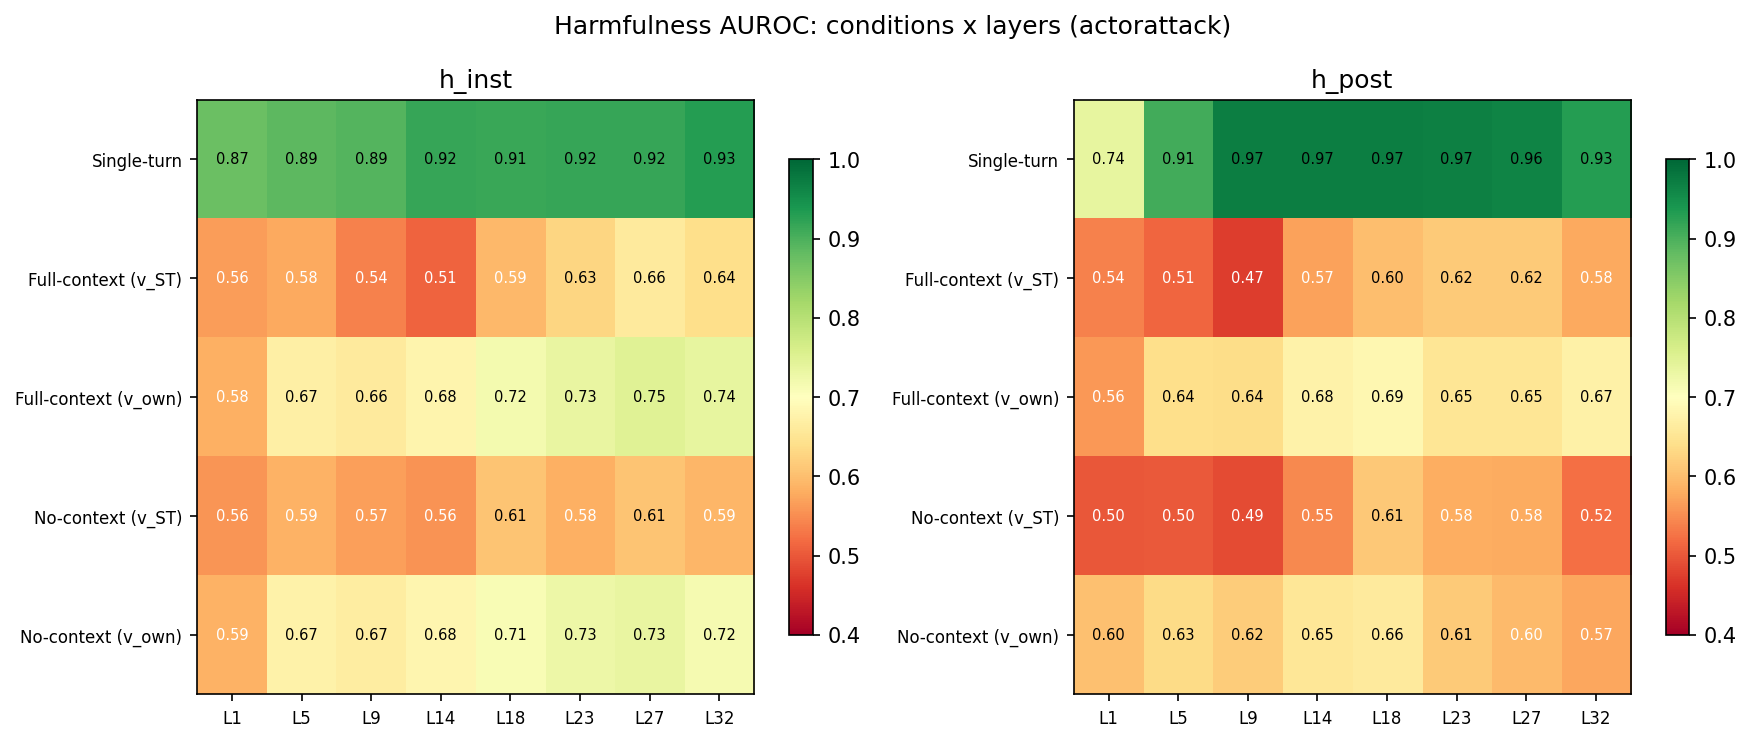

Saved: 09_fig1_auroc_heatmap_actorattack.png

Framework: crescendo


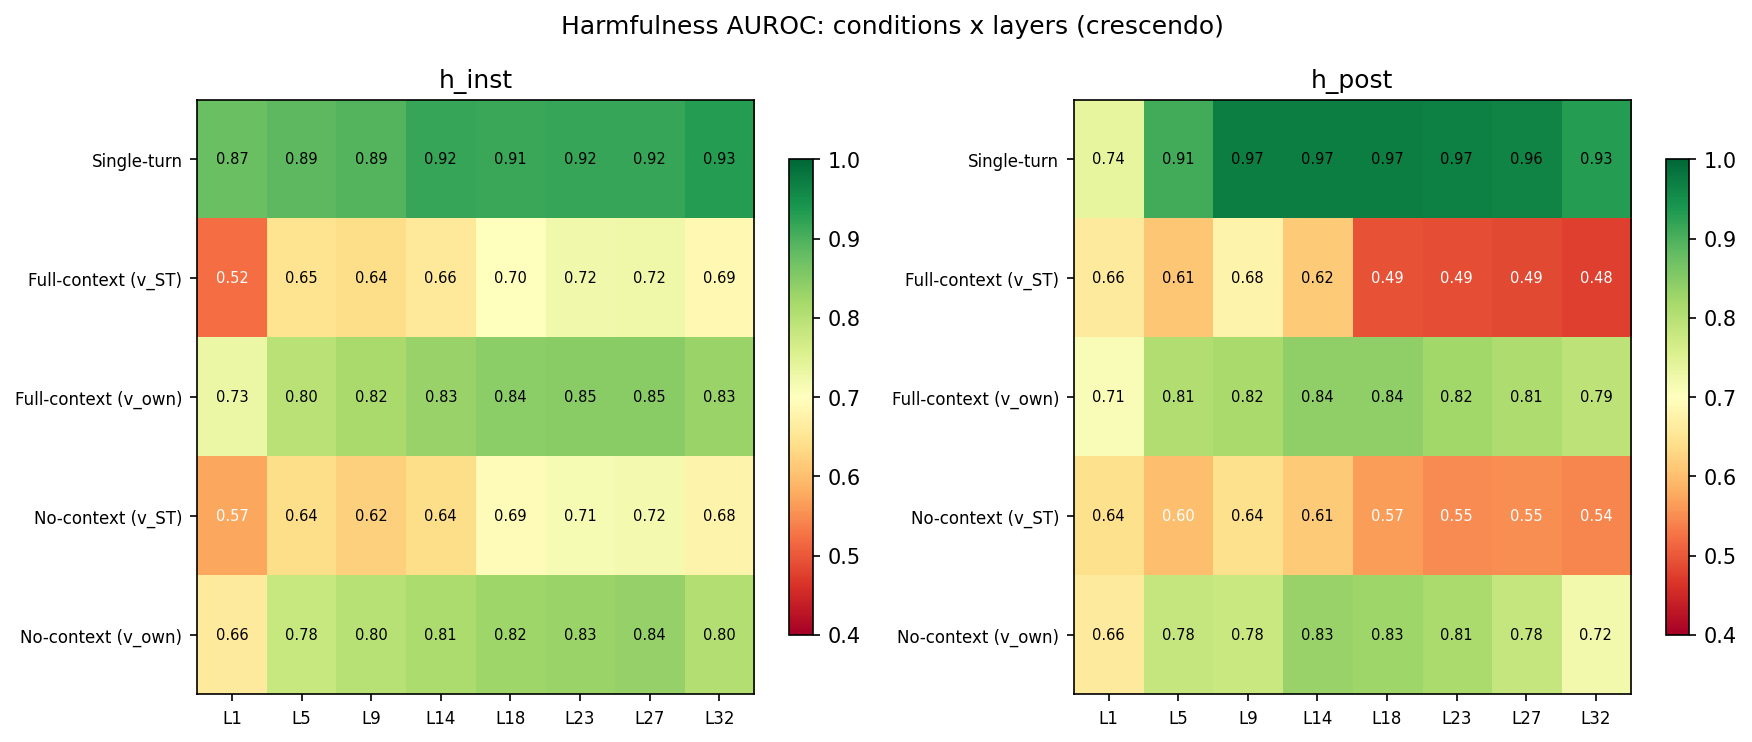

Saved: 09_fig1_auroc_heatmap_crescendo.png

Framework: xteaming


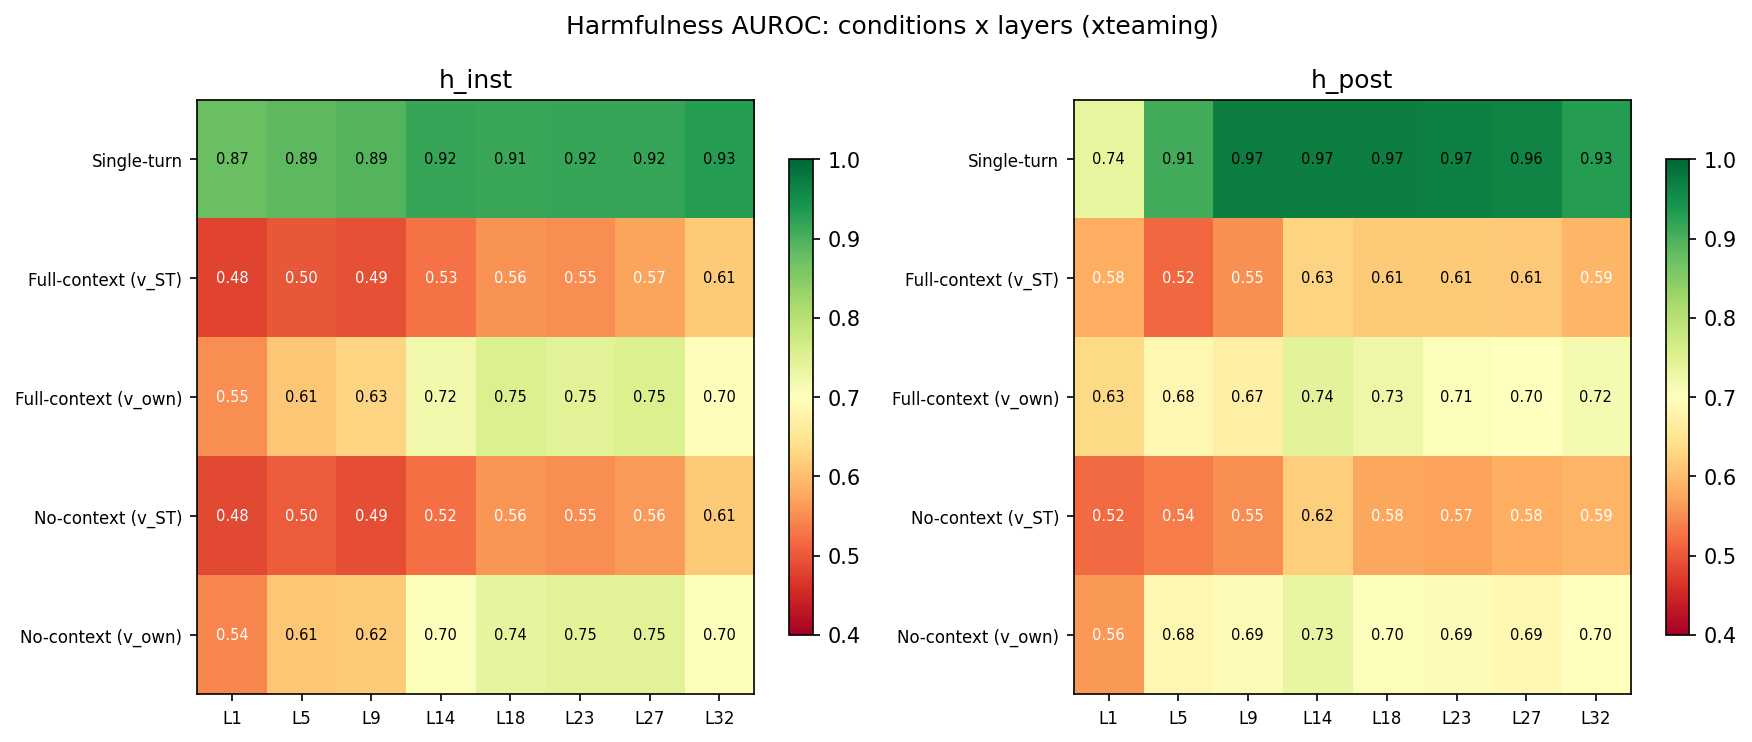

Saved: 09_fig1_auroc_heatmap_xteaming.png


In [4]:
def auroc_projection(h_array, meta, direction, layer, pos_idx=None):
    """
    Project data onto direction at given layer, return AUROC (harmful vs benign).
    pos_idx: optional positional indices to subset.
    """
    if direction is None:
        return np.nan
    if pos_idx is not None:
        h = h_array[pos_idx, layer, :].astype(np.float32)
        m = meta.iloc[pos_idx] if isinstance(pos_idx, np.ndarray) else meta
    else:
        h = h_array[:, layer, :].astype(np.float32)
        m = meta
    proj = h @ direction
    labels = (m['goal_type'].values == 'harmful').astype(int)
    if labels.sum() < 5 or (1 - labels).sum() < 5:
        return np.nan
    return roc_auc_score(labels, proj)

# ── Build AUROC heatmap per framework ─────────────────────────────────────────
for FW in avail_fw:
    print(f'\n{"=" * 60}')
    print(f'Framework: {FW}')
    print(f'{"=" * 60}')

    auroc_table = []

    # Single-turn (same for all frameworks)
    h_st_all = np.concatenate([st['harmful']['h_inst'][m_st_h.index],
                               st['benign']['h_inst'][m_st_b.index]], axis=0)
    hp_st_all = np.concatenate([st['harmful']['h_post'][m_st_h.index],
                                st['benign']['h_post'][m_st_b.index]], axis=0)
    m_st_all = pd.concat([m_st_h.assign(goal_type='harmful'),
                          m_st_b.assign(goal_type='benign')], ignore_index=True)
    aucs_i, aucs_p = {}, {}
    for li in VERIFY_LAYERS:
        aucs_i[li] = auroc_projection(h_st_all, m_st_all, v_harmful_st[li], li)
        aucs_p[li] = auroc_projection(hp_st_all, m_st_all, v_harmful_st[('post', li)], li)
    auroc_table.append(('Single-turn', aucs_i, aucs_p))

    # Full-context and No-context
    for cond_name, data_dict in [('Full-context', traj), ('No-context', nc)]:
        if (FW, 'harmful') not in data_dict:
            continue
        d_h = data_dict[(FW, 'harmful')]
        d_b = data_dict[(FW, 'benign')]
        ft_h = get_final_turn(d_h)
        ft_b = get_final_turn(d_b)
        m_fh = d_h['meta'].loc[ft_h]
        m_fb = d_b['meta'].loc[ft_b]
        test_h = (m_fh['data_split'] == 'test').values
        test_b = (m_fb['data_split'] == 'test').values

        h_all = np.concatenate([d_h['h_inst'][ft_h[test_h]],
                                d_b['h_inst'][ft_b[test_b]]], axis=0)
        hp_all = np.concatenate([d_h['h_post'][ft_h[test_h]],
                                 d_b['h_post'][ft_b[test_b]]], axis=0)
        m_all = pd.concat([
            m_fh[test_h].assign(goal_type='harmful'),
            m_fb[test_b].assign(goal_type='benign')
        ], ignore_index=True)

        # With single-turn direction
        aucs_i, aucs_p = {}, {}
        for li in VERIFY_LAYERS:
            aucs_i[li] = auroc_projection(h_all, m_all, v_harmful_st[li], li)
            aucs_p[li] = auroc_projection(hp_all, m_all, v_harmful_st[('post', li)], li)
        auroc_table.append((f'{cond_name} (v_ST)', aucs_i, aucs_p))

        # With per-condition direction
        aucs_i2, aucs_p2 = {}, {}
        for li in VERIFY_LAYERS:
            v_i = v_harmful_traj.get((FW, str(li)))
            v_p = v_harmful_traj.get((FW, 'post_' + str(li)))
            aucs_i2[li] = auroc_projection(h_all, m_all, v_i, li)
            aucs_p2[li] = auroc_projection(hp_all, m_all, v_p, li)
        auroc_table.append((f'{cond_name} (v_own)', aucs_i2, aucs_p2))

    # Plot
    n_rows = len(auroc_table)
    fig, axes = plt.subplots(1, 2, figsize=(12, 0.6 * n_rows + 2))

    for ax_idx, (pos_label, col_idx) in enumerate([('h_inst', 1), ('h_post', 2)]):
        ax = axes[ax_idx]
        matrix = np.array([[row[col_idx].get(li, np.nan) for li in VERIFY_LAYERS]
                           for row in auroc_table])
        im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0.4, vmax=1.0)
        ax.set_xticks(range(N_VERIFY))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.set_yticks(range(n_rows))
        ax.set_yticklabels([r[0] for r in auroc_table], fontsize=8)
        ax.set_title(pos_label)
        for i in range(n_rows):
            for j in range(N_VERIFY):
                v = matrix[i, j]
                if not np.isnan(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                            color='white' if v < 0.6 else 'black')
        plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(f'Harmfulness AUROC: conditions x layers ({FW})', fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'09_fig1_auroc_heatmap_{FW}.png')
    plt.show()
    print(f'Saved: 09_fig1_auroc_heatmap_{FW}.png')

## 2. Position specificity (Zhao et al. core claim)

**Prediction:** h_inst encodes harmfulness, h_post encodes refusal.

Test: compute AUROC for two tasks at each position:
- **Harmfulness task:** harmful vs benign (goal_type)
- **Refusal task:** refused_harmful vs accepted_harmful (attack_success, harmful only)

If Zhao et al. holds: harmfulness AUROC should be higher at h_inst;
refusal AUROC should be higher at h_post.

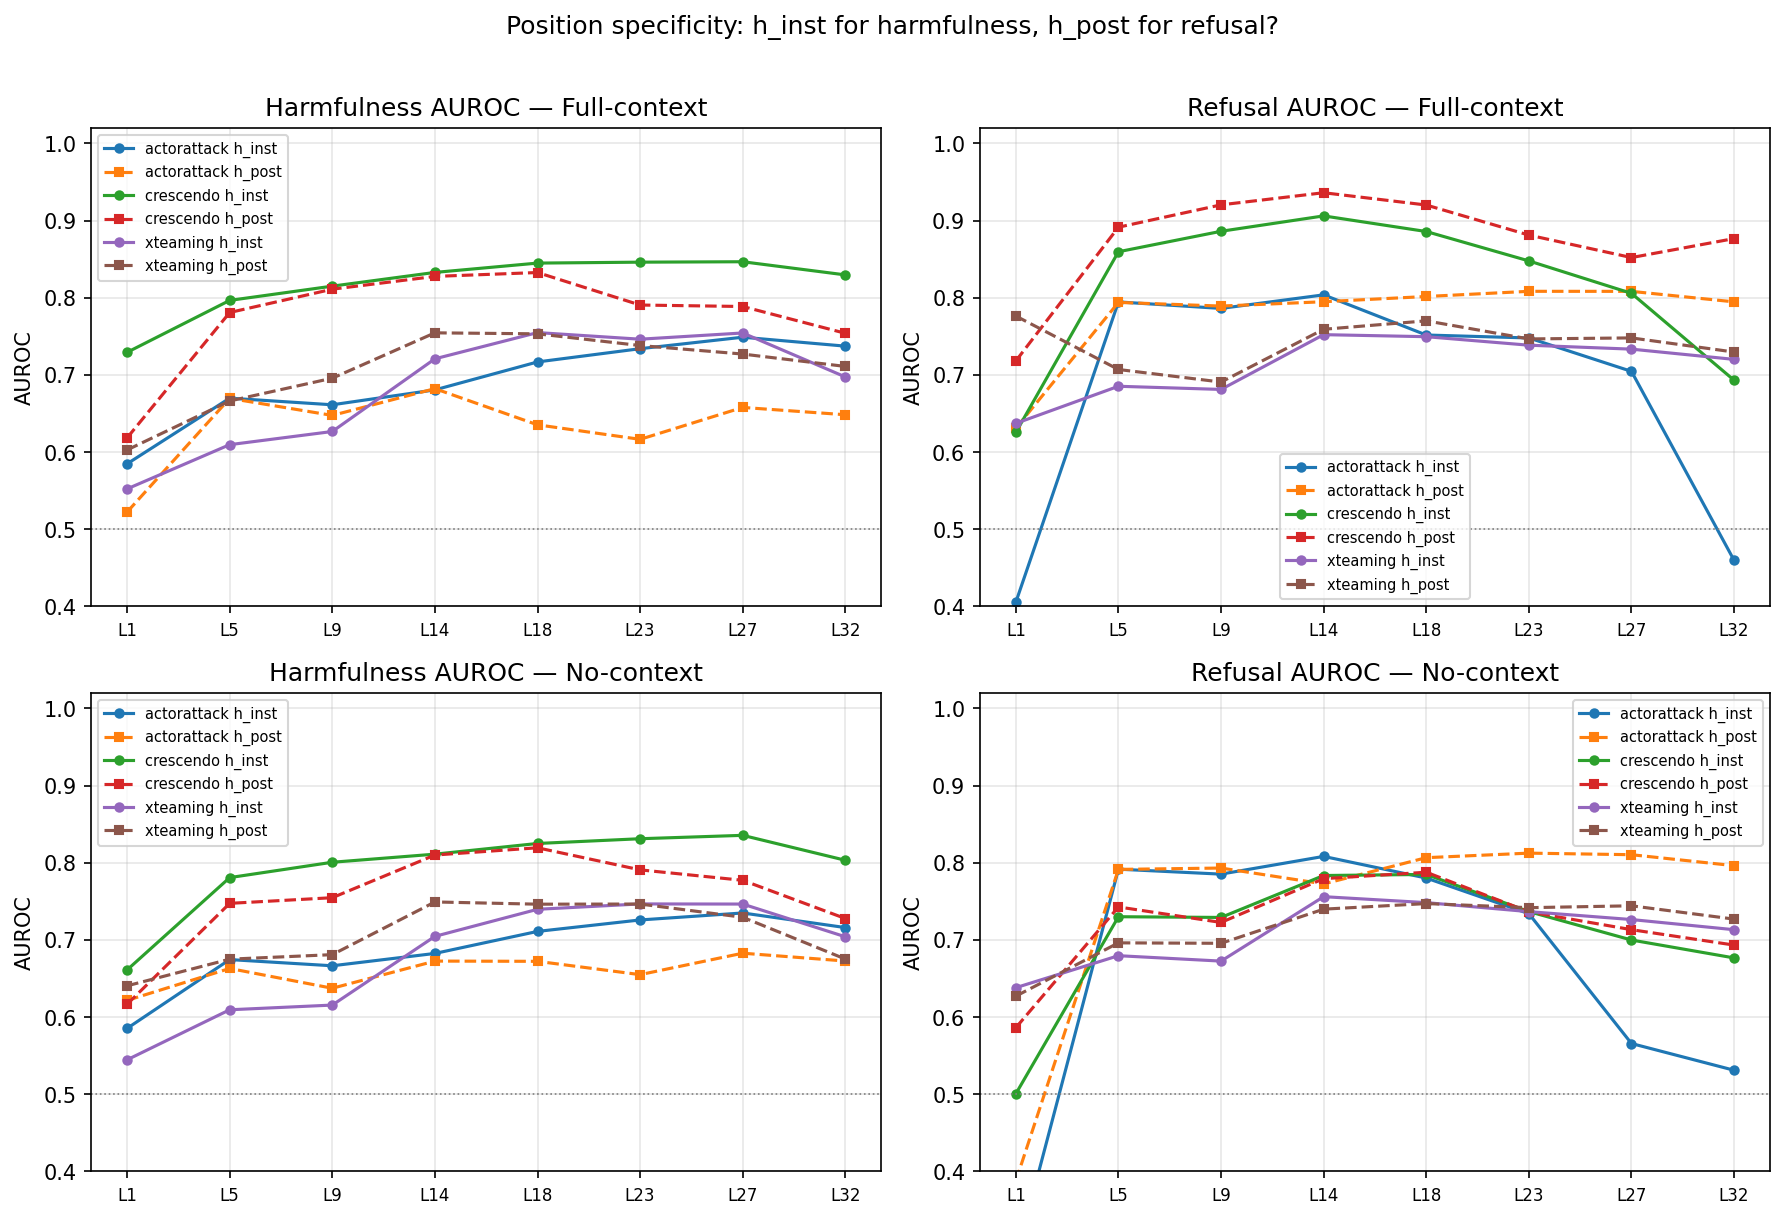

Saved: 09_fig2_position_specificity.png


In [5]:
def refusal_auroc(data_dict, fw, h_key, direction, layer):
    """AUROC for refused vs accepted on harmful conversations (test split, final turn)."""
    d_h = data_dict.get((fw, 'harmful'))
    if d_h is None or direction is None:
        return np.nan
    ft = get_final_turn(d_h)
    m = d_h['meta'].loc[ft]
    test_mask = (m['data_split'] == 'test').values
    m_test = m[test_mask]
    h = d_h[h_key][ft[test_mask], layer, :].astype(np.float32)
    labels = (m_test['attack_success'].values == False).astype(int)  # 1 = refused
    if labels.sum() < 5 or (1 - labels).sum() < 5:
        return np.nan
    proj = h @ direction
    return roc_auc_score(labels, proj)

# ── Compute for each condition ────────────────────────────────────────────────
conditions = [('Full-context', traj)]
if has_nc:
    conditions.append(('No-context', nc))

fig, axes = plt.subplots(len(conditions), 2, figsize=(12, 4 * len(conditions)),
                         squeeze=False)

for row, (cond_label, data_dict) in enumerate(conditions):
    for fw in avail_fw:
        harm_auroc_inst, harm_auroc_post = [], []
        ref_auroc_inst, ref_auroc_post = [], []

        for li in VERIFY_LAYERS:
            v_h = v_harmful_traj.get((fw, str(li)))
            v_r = v_refusal_traj.get((fw, li))

            # Harmfulness AUROC at each position
            d_h = data_dict.get((fw, 'harmful'))
            d_b = data_dict.get((fw, 'benign'))
            if d_h is not None and d_b is not None and v_h is not None:
                ft_h = get_final_turn(d_h)
                ft_b = get_final_turn(d_b)
                m_fh = d_h['meta'].loc[ft_h]
                m_fb = d_b['meta'].loc[ft_b]
                test_h = (m_fh['data_split'] == 'test').values
                test_b = (m_fb['data_split'] == 'test').values

                for h_key, store in [('h_inst', harm_auroc_inst), ('h_post', harm_auroc_post)]:
                    h_all = np.concatenate([d_h[h_key][ft_h[test_h], li, :],
                                           d_b[h_key][ft_b[test_b], li, :]], axis=0).astype(np.float32)
                    labels = np.concatenate([np.ones(test_h.sum()), np.zeros(test_b.sum())])
                    proj = h_all @ v_h
                    store.append(roc_auc_score(labels, proj) if len(labels) > 10 else np.nan)
            else:
                harm_auroc_inst.append(np.nan)
                harm_auroc_post.append(np.nan)

            # Refusal AUROC at each position
            for h_key, store in [('h_inst', ref_auroc_inst), ('h_post', ref_auroc_post)]:
                store.append(refusal_auroc(data_dict, fw, h_key, v_r, li))

        # Plot
        ax_harm = axes[row, 0]
        ax_ref  = axes[row, 1]

        ax_harm.plot(range(N_VERIFY), harm_auroc_inst, 'o-', label=f'{fw} h_inst', lw=1.5, ms=4)
        ax_harm.plot(range(N_VERIFY), harm_auroc_post, 's--', label=f'{fw} h_post', lw=1.5, ms=4)

        ax_ref.plot(range(N_VERIFY), ref_auroc_inst, 'o-', label=f'{fw} h_inst', lw=1.5, ms=4)
        ax_ref.plot(range(N_VERIFY), ref_auroc_post, 's--', label=f'{fw} h_post', lw=1.5, ms=4)

    for ci, (ax, task_label) in enumerate([(axes[row, 0], 'Harmfulness AUROC'),
                                           (axes[row, 1], 'Refusal AUROC')]):
        ax.set_xticks(range(N_VERIFY))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.set_ylabel('AUROC')
        ax.set_ylim(0.4, 1.02)
        ax.axhline(0.5, color='gray', ls=':', lw=0.8)
        ax.set_title(f'{task_label} — {cond_label}')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

fig.suptitle('Position specificity: h_inst for harmfulness, h_post for refusal?', y=1.01, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / '09_fig2_position_specificity.png')
plt.show()
print('Saved: 09_fig2_position_specificity.png')

## 3. Silhouette scores — geometric separability

Measures cluster quality without assuming a specific direction.
Subsampled to 300 per class for tractability in 4096-d.

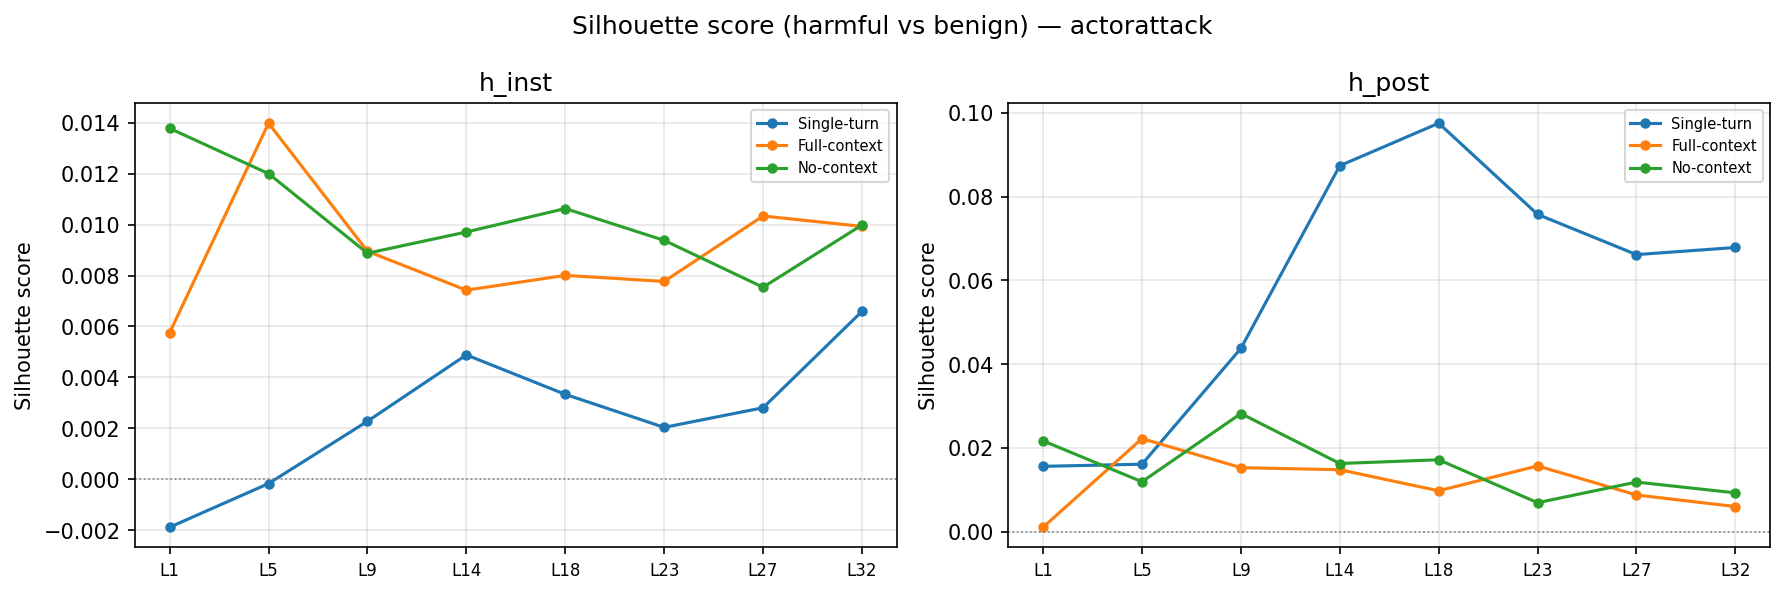

Saved: 09_fig3_silhouette_actorattack.png


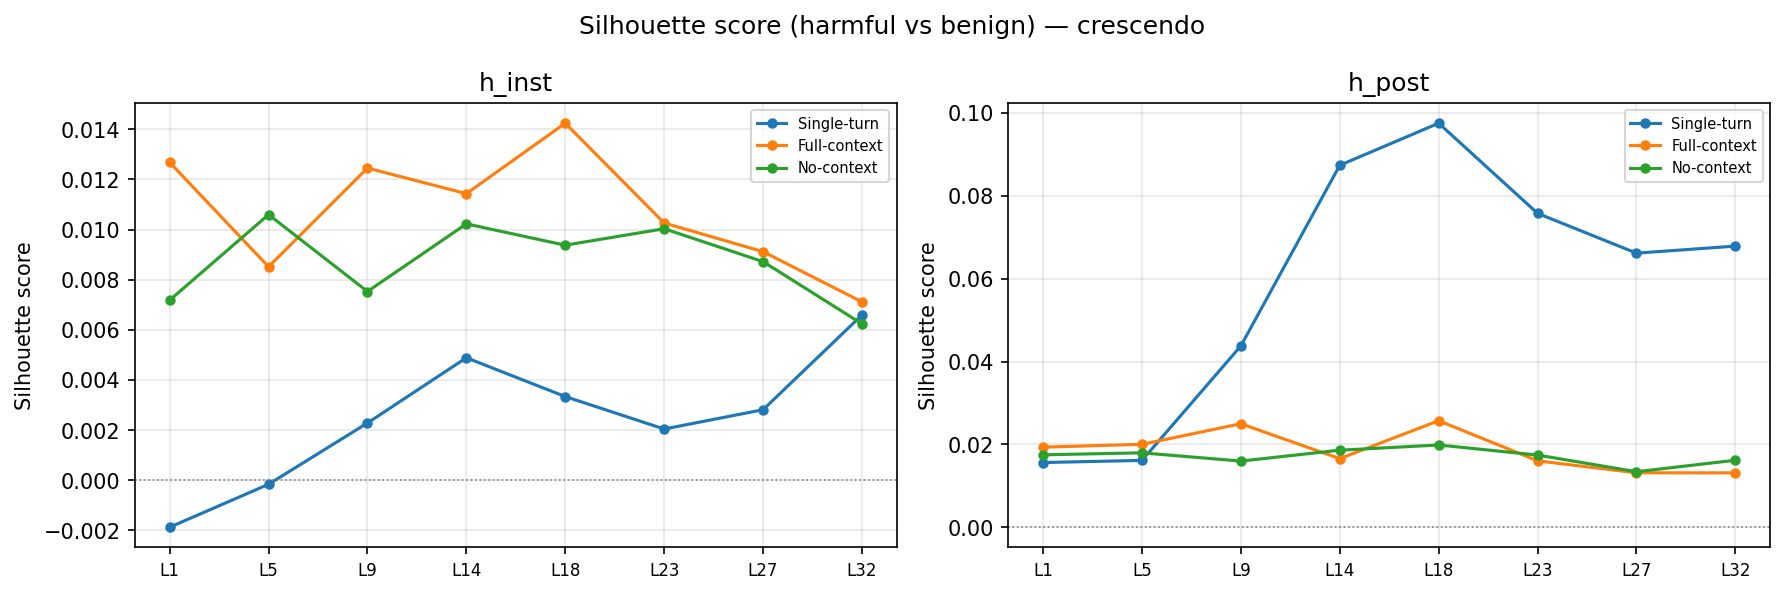

Saved: 09_fig3_silhouette_crescendo.png


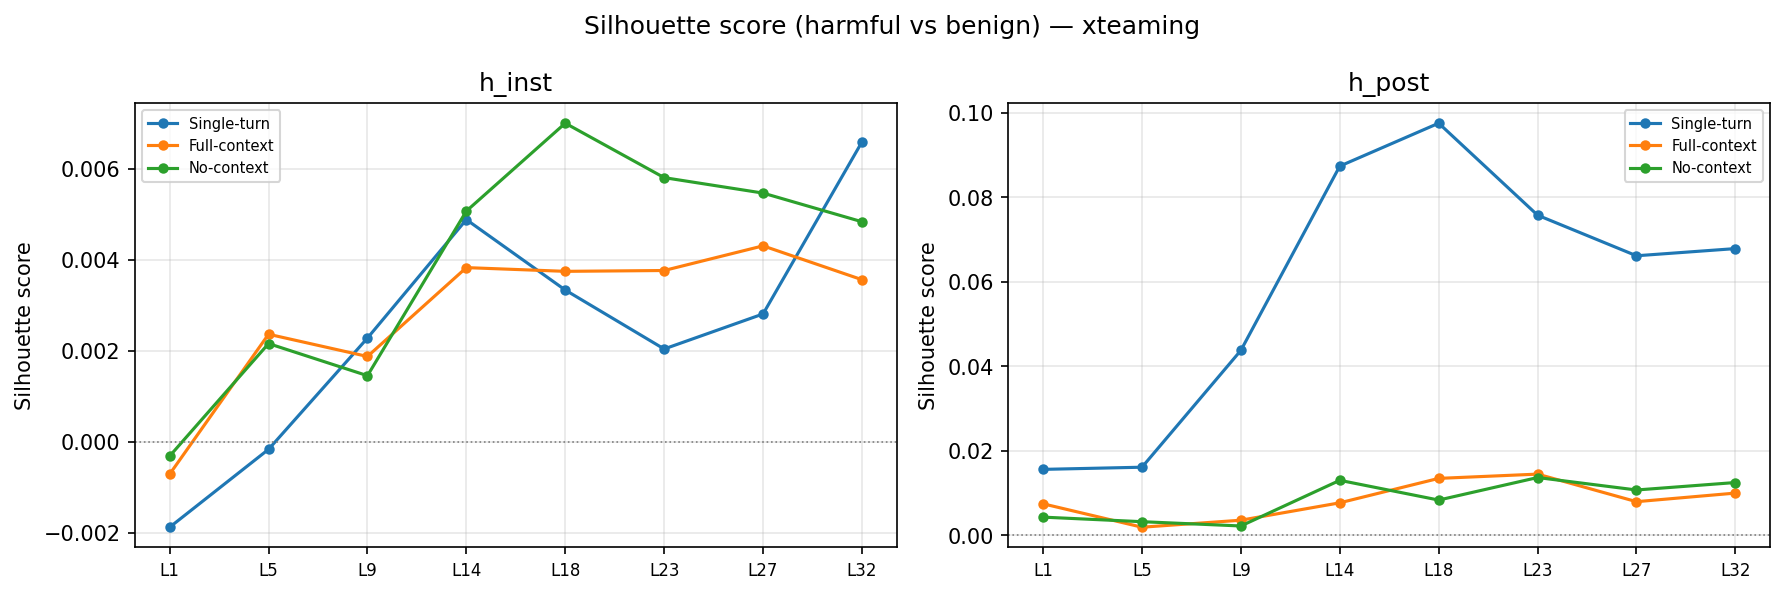

Saved: 09_fig3_silhouette_xteaming.png


In [6]:
SUBSAMPLE = 300
rng = np.random.RandomState(42)

def silhouette_for_condition(h_harm, h_ben, layer):
    """Compute silhouette score at a single layer, subsampled."""
    h_h = h_harm[:, layer, :].astype(np.float32)
    h_b = h_ben[:, layer, :].astype(np.float32)
    n_h = min(SUBSAMPLE, len(h_h))
    n_b = min(SUBSAMPLE, len(h_b))
    idx_h = rng.choice(len(h_h), n_h, replace=False)
    idx_b = rng.choice(len(h_b), n_b, replace=False)
    X = np.concatenate([h_h[idx_h], h_b[idx_b]], axis=0)
    labels = np.concatenate([np.ones(n_h), np.zeros(n_b)])
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels, metric='euclidean', sample_size=min(1000, len(X)))

for FW in avail_fw:
    sil_results = []

    # Single-turn
    s_i, s_p = {}, {}
    for li in VERIFY_LAYERS:
        s_i[li] = silhouette_for_condition(
            st['harmful']['h_inst'][m_st_h.index],
            st['benign']['h_inst'][m_st_b.index], li)
        s_p[li] = silhouette_for_condition(
            st['harmful']['h_post'][m_st_h.index],
            st['benign']['h_post'][m_st_b.index], li)
    sil_results.append(('Single-turn', s_i, s_p))

    for cond_label, data_dict in [('Full-context', traj), ('No-context', nc)]:
        if (FW, 'harmful') not in data_dict:
            continue
        d_h = data_dict[(FW, 'harmful')]
        d_b = data_dict[(FW, 'benign')]
        ft_h = get_final_turn(d_h)
        ft_b = get_final_turn(d_b)
        s_i, s_p = {}, {}
        for li in VERIFY_LAYERS:
            s_i[li] = silhouette_for_condition(d_h['h_inst'][ft_h], d_b['h_inst'][ft_b], li)
            s_p[li] = silhouette_for_condition(d_h['h_post'][ft_h], d_b['h_post'][ft_b], li)
        sil_results.append((cond_label, s_i, s_p))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax_idx, (pos_label, col_idx) in enumerate([('h_inst', 1), ('h_post', 2)]):
        ax = axes[ax_idx]
        for label, si, sp in sil_results:
            data = si if col_idx == 1 else sp
            ax.plot(range(N_VERIFY), [data[li] for li in VERIFY_LAYERS],
                    'o-', lw=1.5, ms=4, label=label)
        ax.set_xticks(range(N_VERIFY))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.set_ylabel('Silhouette score')
        ax.set_title(f'{pos_label}')
        ax.axhline(0, color='gray', ls=':', lw=0.8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Silhouette score (harmful vs benign) — {FW}', fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'09_fig3_silhouette_{FW}.png')
    plt.show()
    print(f'Saved: 09_fig3_silhouette_{FW}.png')

## 4. Nearest-centroid misbehavior clustering

For each condition and layer: what fraction of refused_harmful is closer to the
accepted_harmful centroid than the benign centroid?

Zhao et al. prediction: ~1.0 at h_inst (model sees it as harmful regardless of refusal).

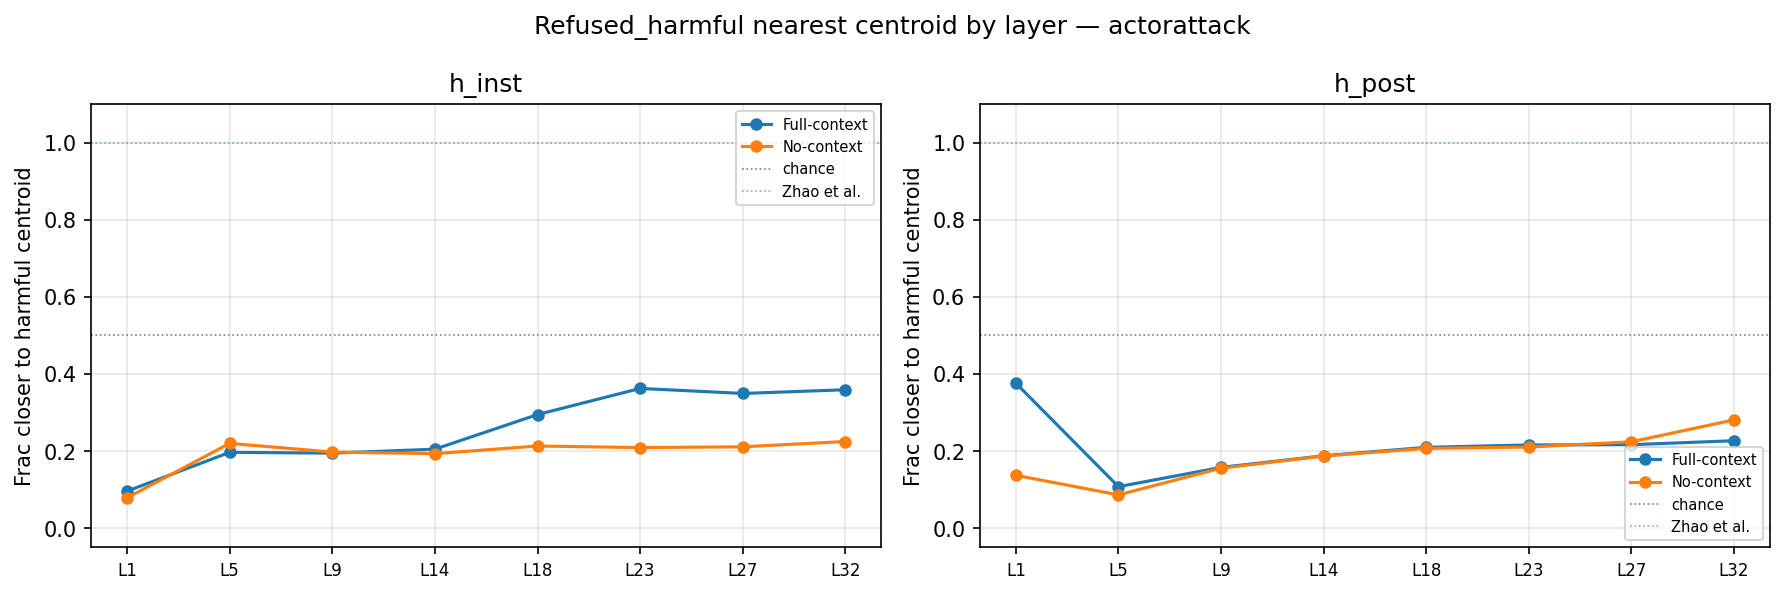

Saved: 09_fig4_nearest_centroid_actorattack.png


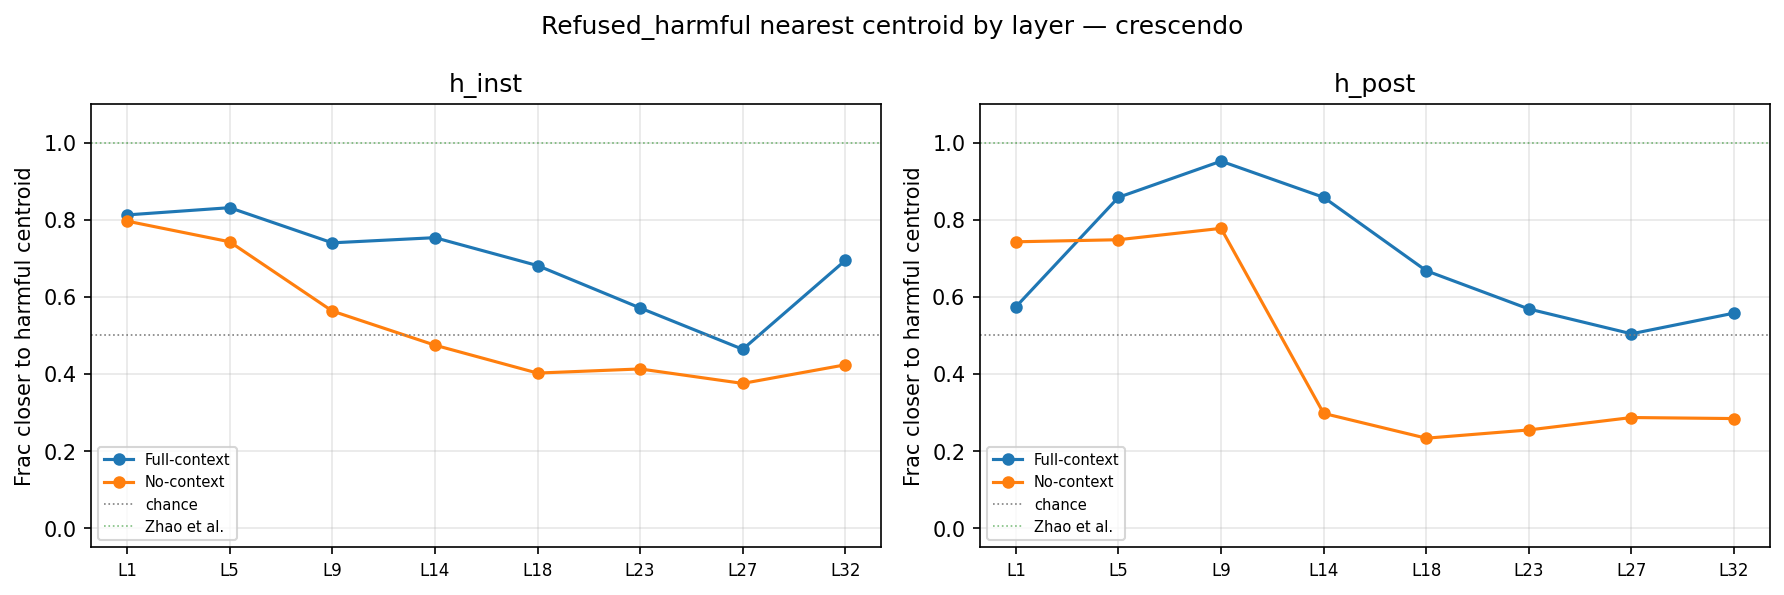

Saved: 09_fig4_nearest_centroid_crescendo.png


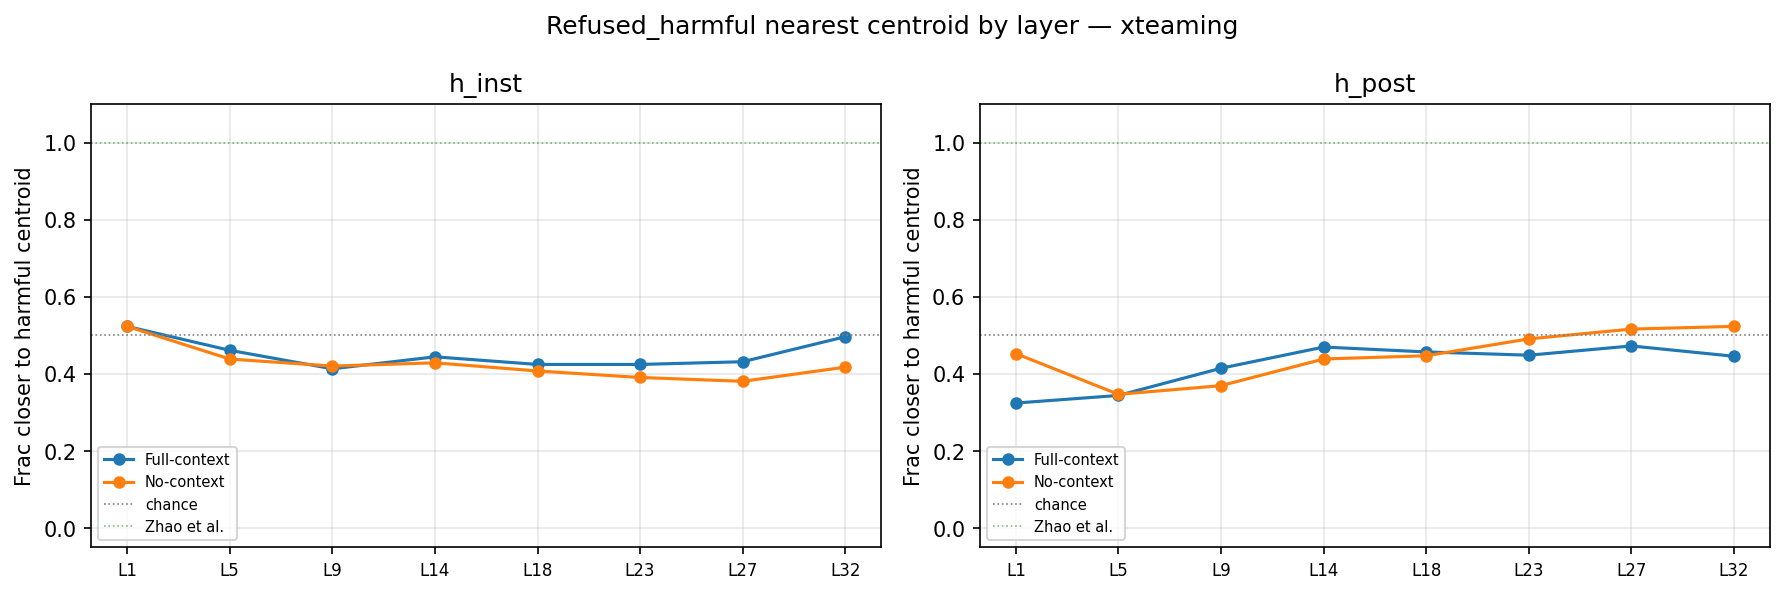

Saved: 09_fig4_nearest_centroid_xteaming.png


In [7]:
def nearest_centroid_fraction(data_dict, fw, h_key, layer):
    """Fraction of refused_harmful closer to harmful centroid. Final turn."""
    d_h = data_dict.get((fw, 'harmful'))
    d_b = data_dict.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return np.nan

    ft_h = get_final_turn(d_h)
    ft_b = get_final_turn(d_b)
    m_fh = d_h['meta'].loc[ft_h]

    acc = (m_fh['attack_success'].values == True)
    ref = ~acc
    if acc.sum() < 5 or ref.sum() < 5:
        return np.nan

    h_acc = d_h[h_key][ft_h[acc], layer, :].astype(np.float32)
    h_ref = d_h[h_key][ft_h[ref], layer, :].astype(np.float32)
    h_ben = d_b[h_key][ft_b, layer, :].astype(np.float32)

    c_acc = h_acc.mean(axis=0)
    c_ben = h_ben.mean(axis=0)

    d_to_acc = np.linalg.norm(h_ref - c_acc, axis=1)
    d_to_ben = np.linalg.norm(h_ref - c_ben, axis=1)
    return (d_to_acc < d_to_ben).mean()

for FW in avail_fw:
    nc_results = []

    for cond_label, data_dict in [('Full-context', traj), ('No-context', nc)]:
        if (FW, 'harmful') not in data_dict:
            continue
        fi, fp = {}, {}
        for li in VERIFY_LAYERS:
            fi[li] = nearest_centroid_fraction(data_dict, FW, 'h_inst', li)
            fp[li] = nearest_centroid_fraction(data_dict, FW, 'h_post', li)
        nc_results.append((cond_label, fi, fp))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax_idx, (pos_label, col_idx) in enumerate([('h_inst', 1), ('h_post', 2)]):
        ax = axes[ax_idx]
        for label, fi, fp in nc_results:
            data = fi if col_idx == 1 else fp
            ax.plot(range(N_VERIFY), [data[li] for li in VERIFY_LAYERS],
                    'o-', lw=1.5, ms=5, label=label)
        ax.axhline(0.5, color='gray', ls=':', lw=0.8, label='chance')
        ax.axhline(1.0, color='green', ls=':', lw=0.8, alpha=0.5, label='Zhao et al.')
        ax.set_xticks(range(N_VERIFY))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.set_ylabel('Frac closer to harmful centroid')
        ax.set_title(pos_label)
        ax.set_ylim(-0.05, 1.1)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'Refused_harmful nearest centroid by layer — {FW}', fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'09_fig4_nearest_centroid_{FW}.png')
    plt.show()
    print(f'Saved: 09_fig4_nearest_centroid_{FW}.png')

## 5. Per-turn × layer AUROC heatmap (slowest)

Full sweep: at each (turn k, layer), compute harmfulness AUROC using the
per-turn direction from train data, evaluated on test data.

Shows how the signal evolves across both turns and layers simultaneously.
Separate panels for full-context and no-context, and for h_inst and h_post.

Turn x Layer (actorattack): 100%|██████████| 320/320 [00:24<00:00, 13.16it/s]


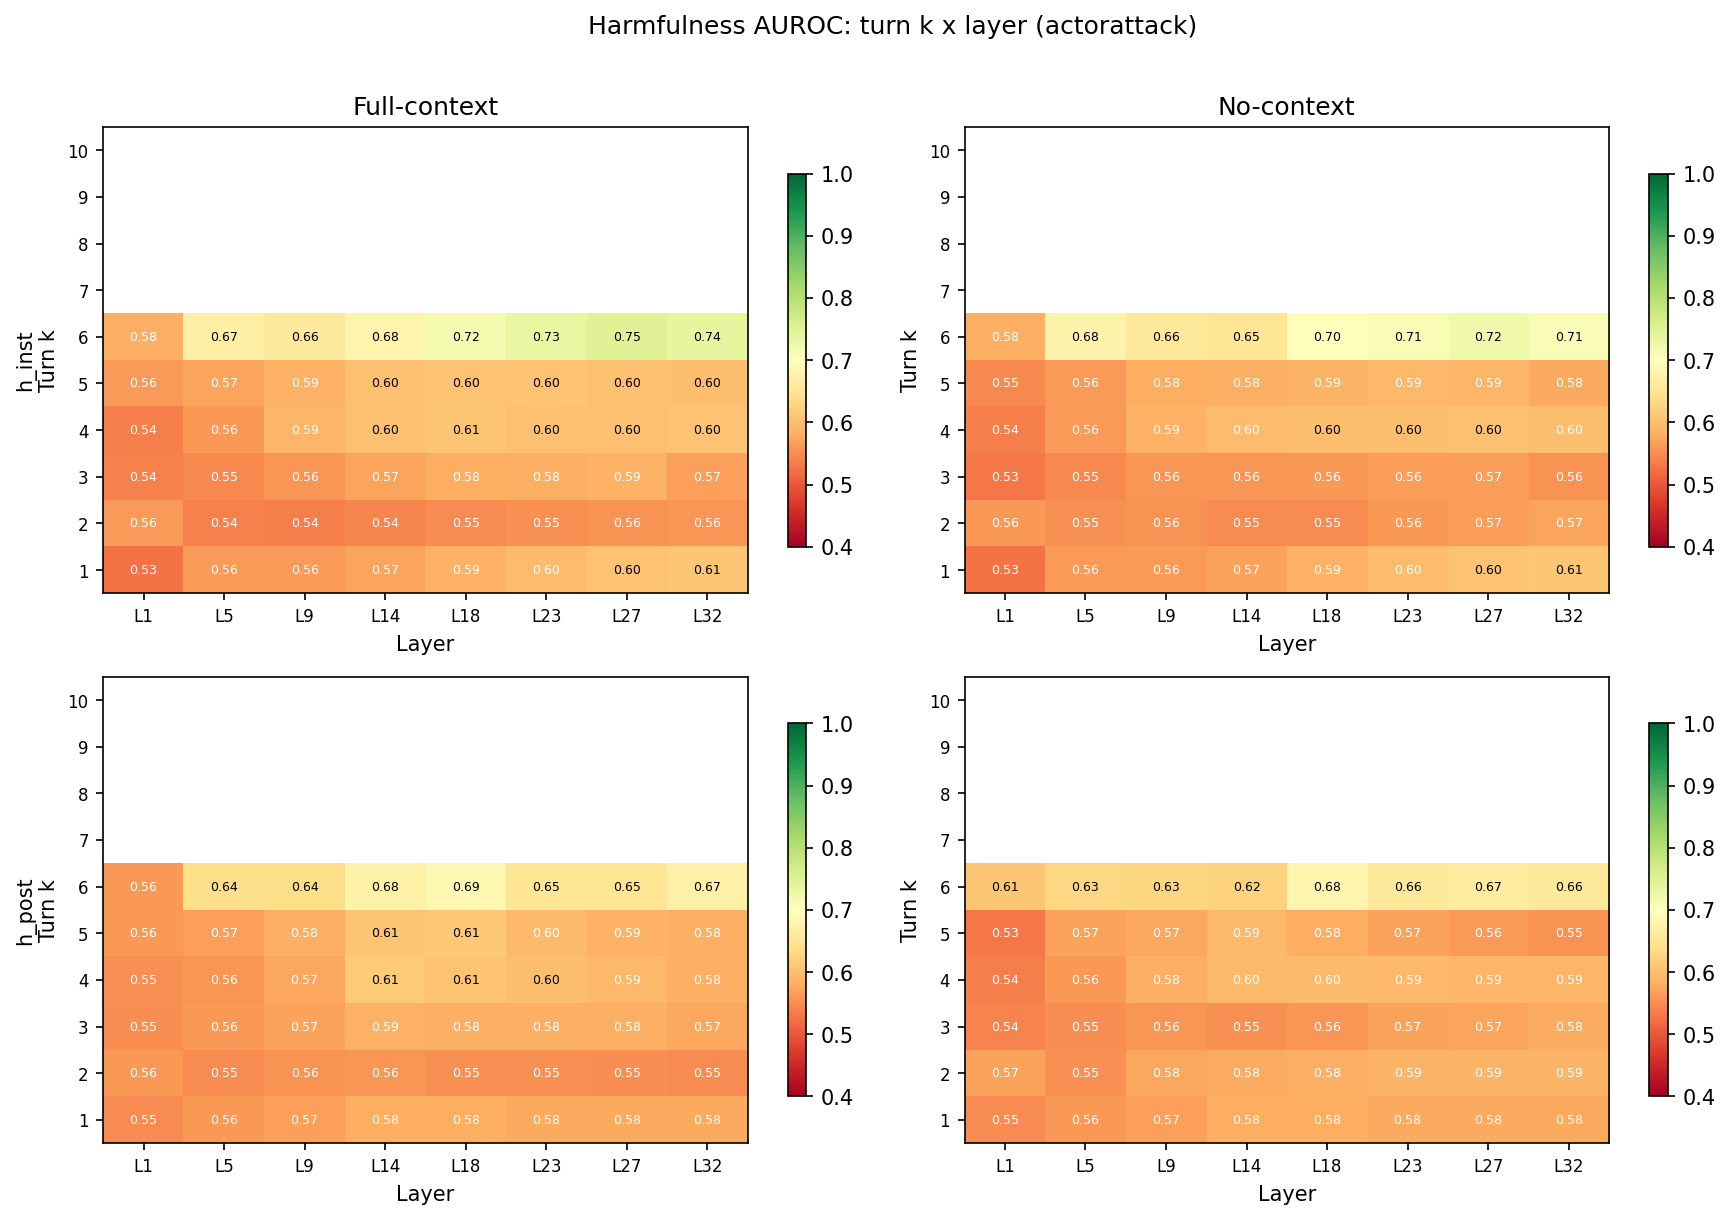

Saved: 09_fig5_turnk_layer_actorattack.png


Turn x Layer (crescendo): 100%|██████████| 320/320 [00:20<00:00, 15.49it/s]


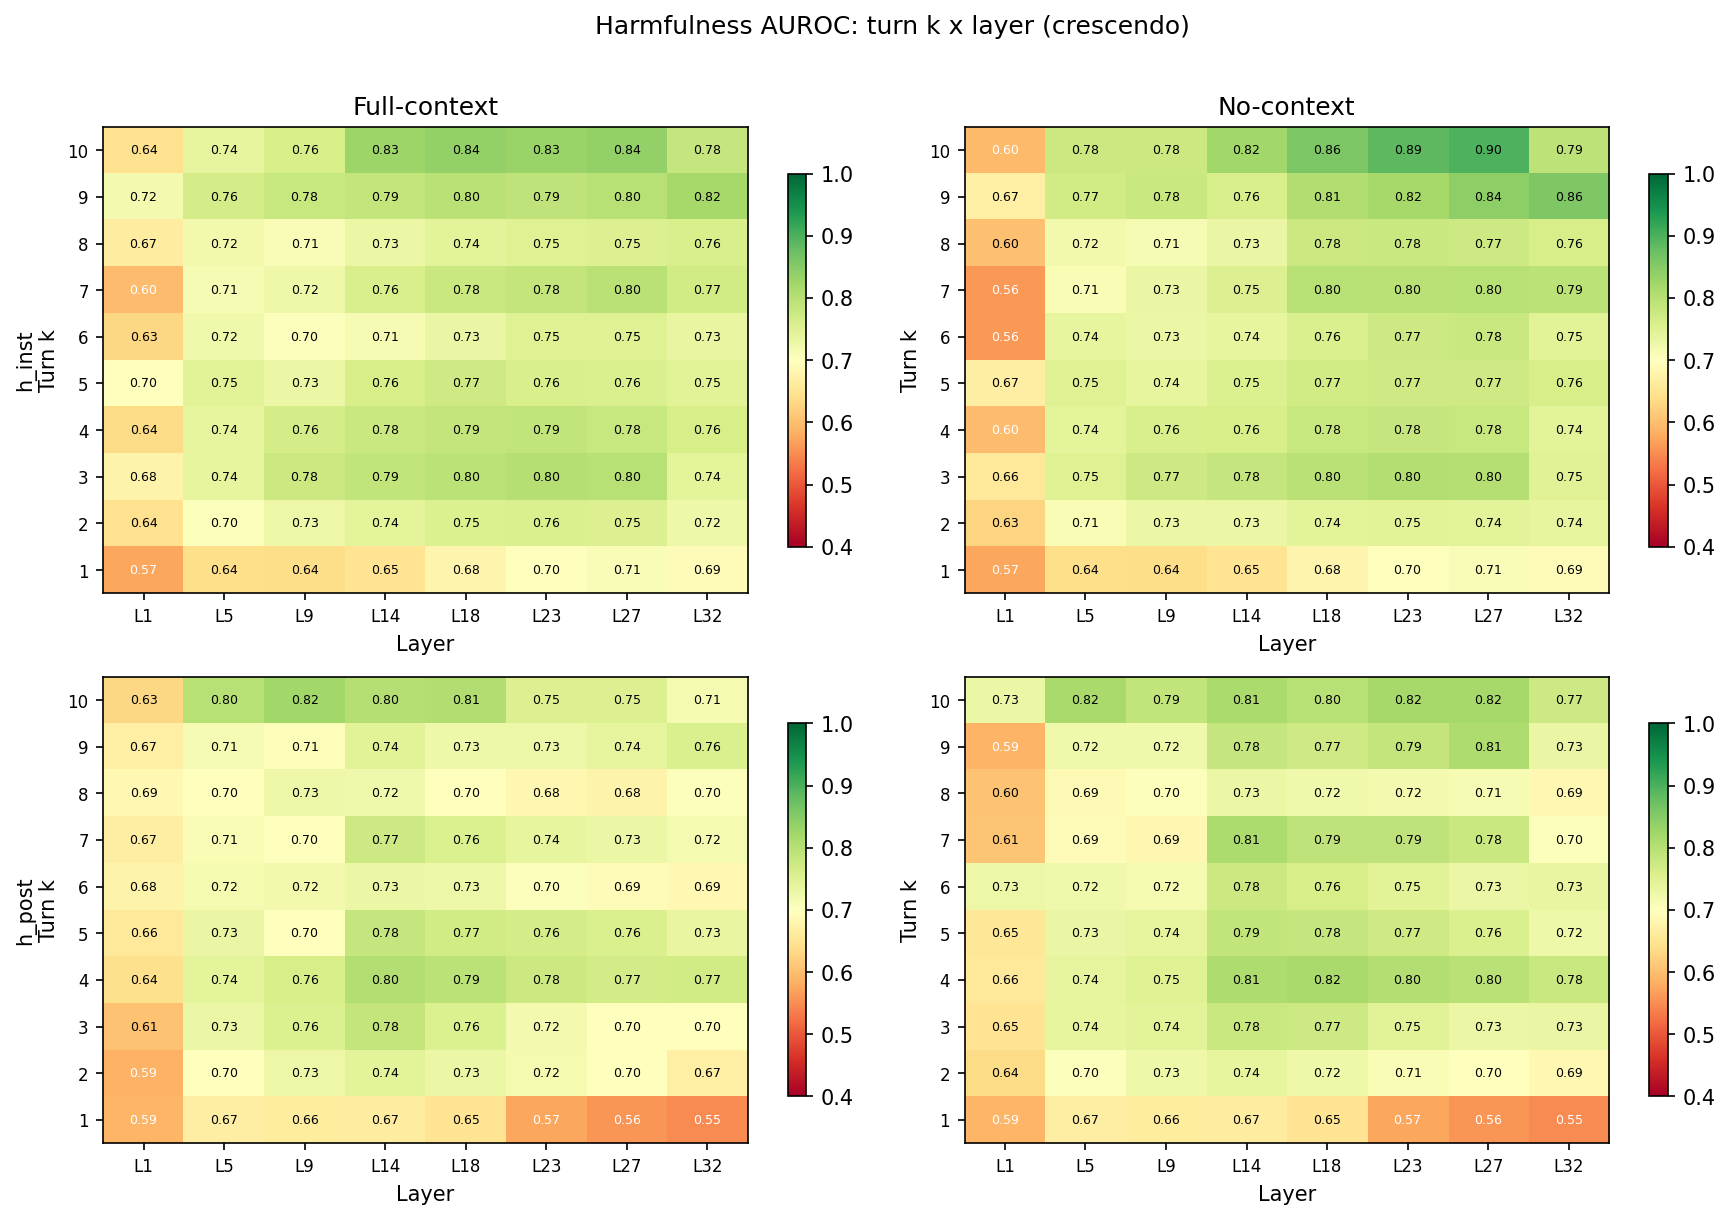

Saved: 09_fig5_turnk_layer_crescendo.png


Turn x Layer (xteaming): 100%|██████████| 320/320 [00:11<00:00, 27.12it/s]


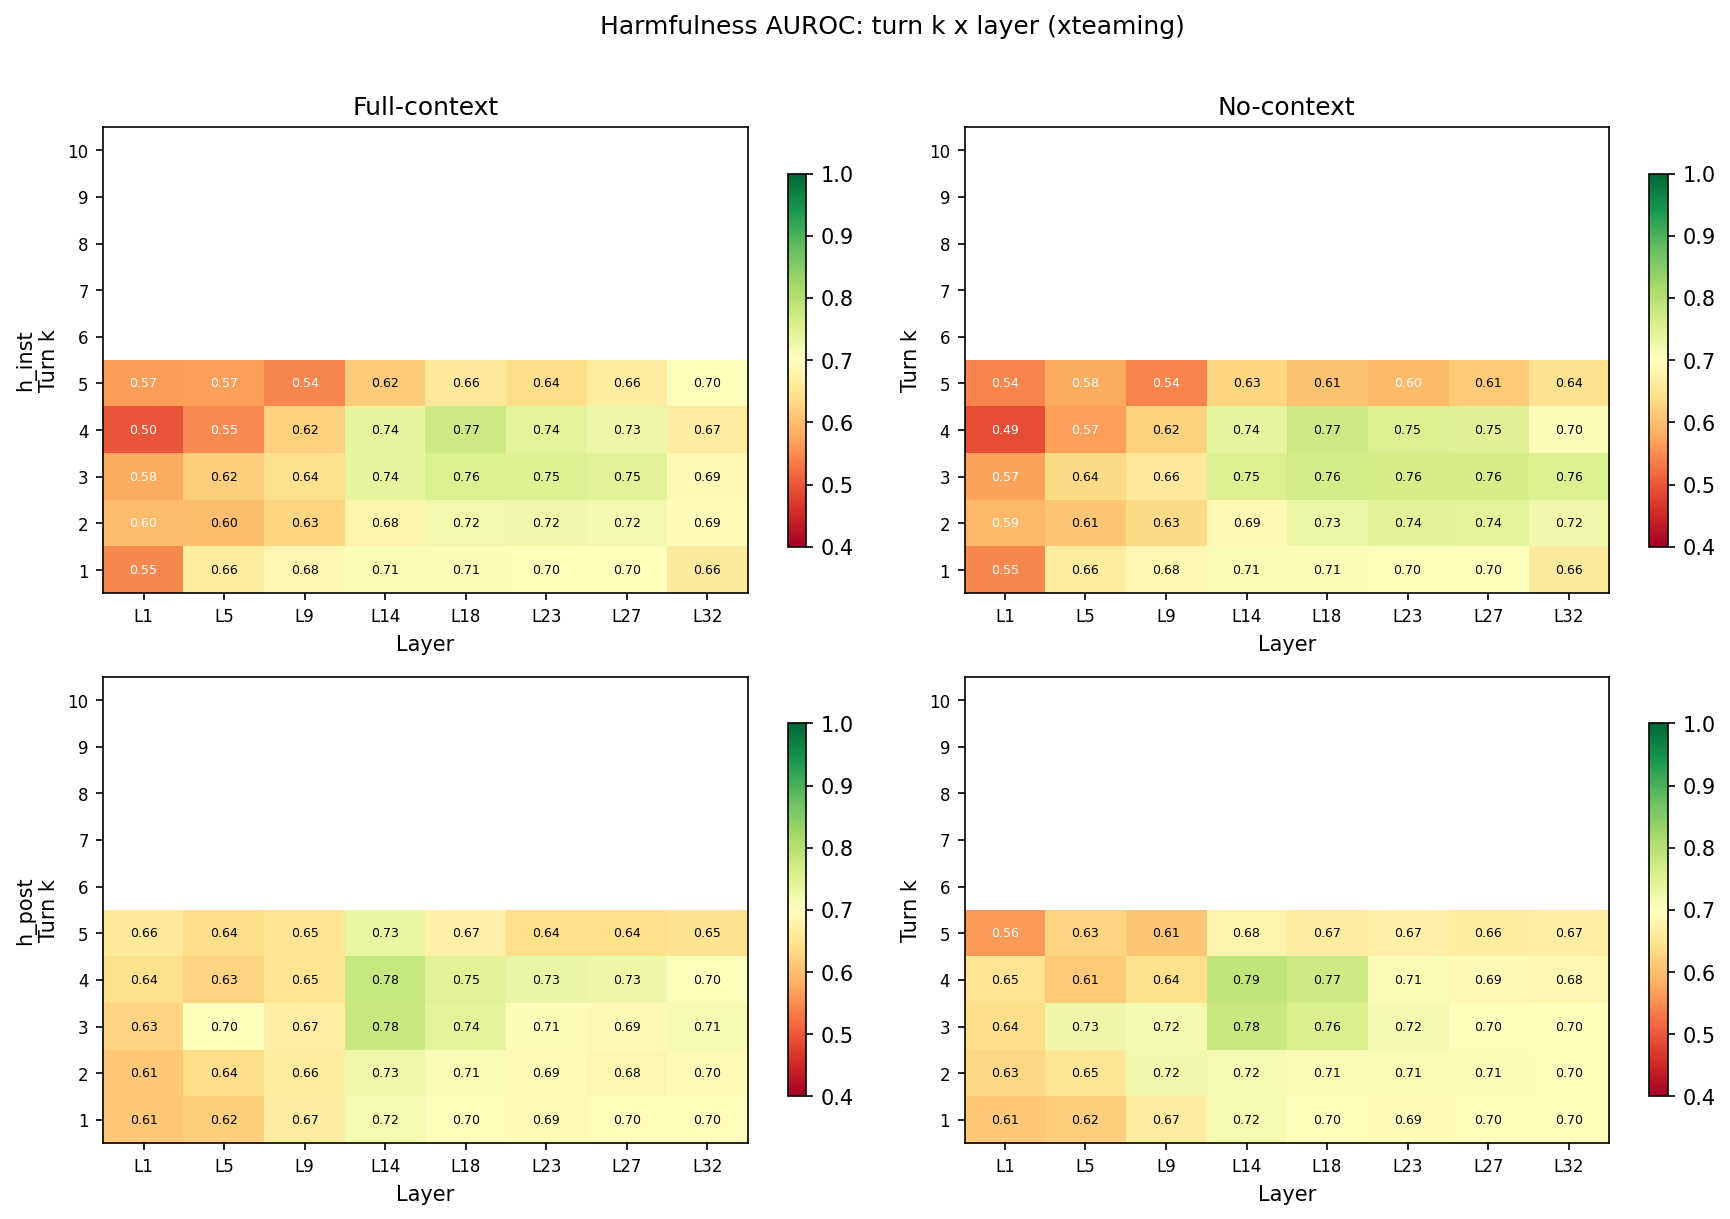

Saved: 09_fig5_turnk_layer_xteaming.png


In [8]:
def auroc_at_k_layer(data_dict, fw, h_key, layer, k):
    """
    Compute within-pair direction at (k, layer) from train,
    then evaluate AUROC on test. Returns AUROC or nan.
    """
    d_h = data_dict.get((fw, 'harmful'))
    d_b = data_dict.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return np.nan

    m_h, m_b = d_h['meta'], d_b['meta']

    tr_h = ((m_h['turn_k'] == k) & (m_h['data_split'] == 'train')).values
    tr_b = ((m_b['turn_k'] == k) & (m_b['data_split'] == 'train')).values
    if tr_h.sum() < 10 or tr_b.sum() < 10:
        return np.nan

    v = paired_direction(
        d_h[h_key][tr_h], m_h[tr_h].reset_index(drop=True),
        d_b[h_key][tr_b], m_b[tr_b].reset_index(drop=True),
        layer
    )
    if v is None:
        return np.nan

    te_h = ((m_h['turn_k'] == k) & (m_h['data_split'] == 'test')).values
    te_b = ((m_b['turn_k'] == k) & (m_b['data_split'] == 'test')).values
    if te_h.sum() < 5 or te_b.sum() < 5:
        return np.nan

    h_te = np.concatenate([d_h[h_key][te_h, layer, :],
                           d_b[h_key][te_b, layer, :]], axis=0).astype(np.float32)
    labels = np.concatenate([np.ones(te_h.sum()), np.zeros(te_b.sum())])
    proj = h_te @ v
    return roc_auc_score(labels, proj)

for FW in avail_fw:
    heatmaps = {}

    cond_list = [('Full-context', traj)]
    if has_nc:
        cond_list.append(('No-context', nc))

    total_iters = len(cond_list) * 2 * MAX_K * N_VERIFY
    pbar = tqdm(total=total_iters, desc=f'Turn x Layer ({FW})')

    for cond_label, data_dict in cond_list:
        for h_key in ['h_inst', 'h_post']:
            mat = np.full((MAX_K, N_VERIFY), np.nan)
            for ki, k in enumerate(range(1, MAX_K + 1)):
                for li_idx, li in enumerate(VERIFY_LAYERS):
                    mat[ki, li_idx] = auroc_at_k_layer(data_dict, FW, h_key, li, k)
                    pbar.update(1)
            heatmaps[(cond_label, h_key)] = mat

    pbar.close()

    # Plot
    n_conds = len(cond_list)
    fig, axes = plt.subplots(2, n_conds, figsize=(6 * n_conds, 8), squeeze=False)

    for col, (cond_label, _) in enumerate(cond_list):
        for row, h_key in enumerate(['h_inst', 'h_post']):
            ax = axes[row, col]
            mat = heatmaps.get((cond_label, h_key))
            if mat is None:
                continue
            im = ax.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=0.4, vmax=1.0,
                           origin='lower')
            ax.set_xticks(range(N_VERIFY))
            ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
            ax.set_yticks(range(MAX_K))
            ax.set_yticklabels(range(1, MAX_K + 1), fontsize=8)
            ax.set_ylabel('Turn k')
            ax.set_xlabel('Layer')
            if row == 0:
                ax.set_title(f'{cond_label}')
            if col == 0:
                ax.set_ylabel(f'{h_key}\nTurn k')
            for i in range(MAX_K):
                for j in range(N_VERIFY):
                    v = mat[i, j]
                    if not np.isnan(v):
                        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                                fontsize=6, color='white' if v < 0.6 else 'black')
            plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(f'Harmfulness AUROC: turn k x layer ({FW})', y=1.01, fontsize=12)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'09_fig5_turnk_layer_{FW}.png')
    plt.show()
    print(f'Saved: 09_fig5_turnk_layer_{FW}.png')

## 6. PCA clustering by condition and layer

PCA scatter of accepted_harmful, refused_harmful, and benign at the final turn.
Columns: extraction conditions (full-context, no-context, single-turn).
One figure per (framework, layer), at selected mid layers + L32.

IndexError: index 15 is out of bounds for axis 1 with size 8

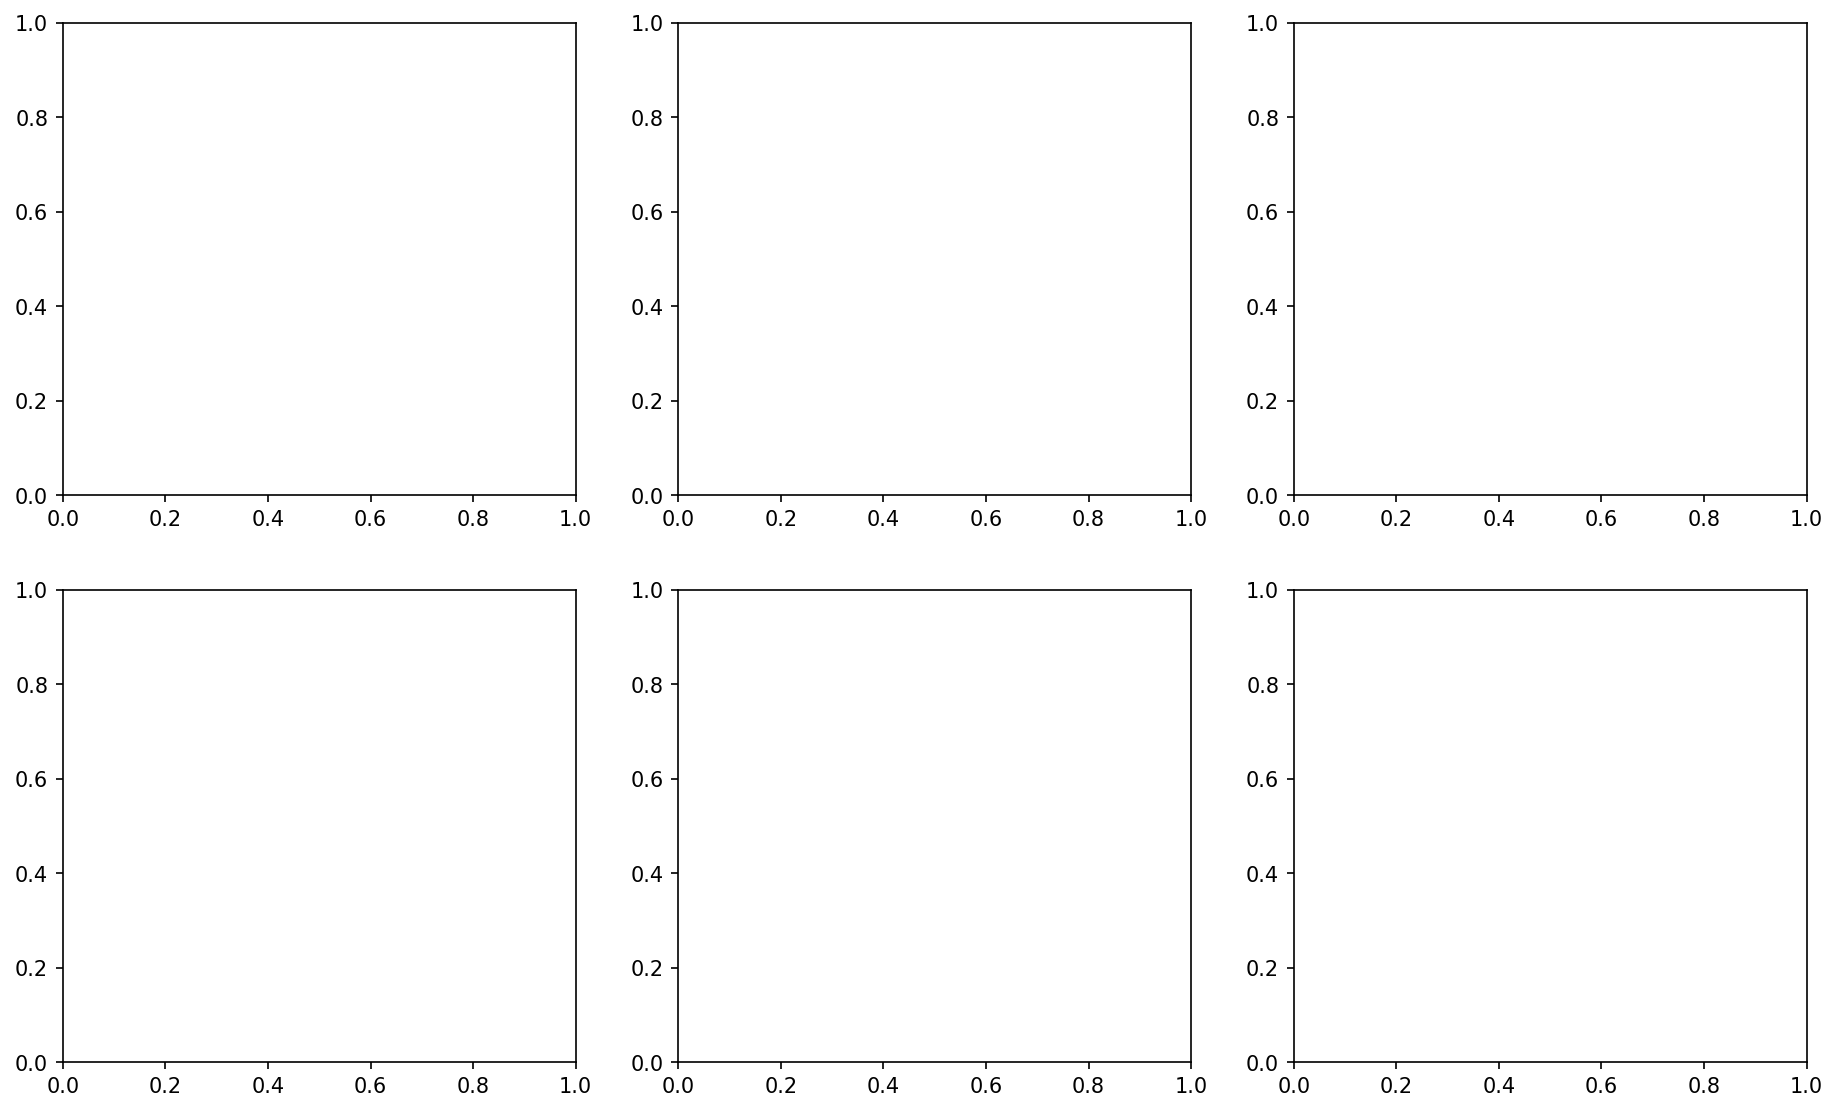

In [9]:
from sklearn.decomposition import PCA

PCA_LAYERS = [15, 19, 31]   # L16, L20, L32
PCA_LABELS = ['L16', 'L20', 'L32']

COLORS = {'accepted_harmful': '#d62728', 'refused_harmful': '#ff9896',
          'benign': '#2ca02c'}

def get_groups_from(data_dict, fw, h_key, layer):
    """Return (h_acc, h_ref, h_ben) at final turn. Works for traj/nc."""
    d_h = data_dict.get((fw, 'harmful'))
    d_b = data_dict.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return None
    ft_h = get_final_turn(d_h)
    m_fh = d_h['meta'].loc[ft_h]
    h_fh = d_h[h_key][ft_h, layer, :].astype(np.float32)
    acc = m_fh['attack_success'].values == True
    ref = ~acc
    h_acc, h_ref = h_fh[acc], h_fh[ref]

    ft_b = get_final_turn(d_b)
    h_ben = d_b[h_key][ft_b, layer, :].astype(np.float32)
    return h_acc, h_ref, h_ben

def get_st_groups(h_key, layer):
    h_harm = st['harmful'][h_key][:, layer, :].astype(np.float32)
    h_ben  = st['benign'][h_key][:, layer, :].astype(np.float32)
    return h_harm, np.empty((0, h_harm.shape[1]), dtype=np.float32), h_ben

for FW in avail_fw:
    conditions = [('Full-context', lambda hk, ly: get_groups_from(traj, FW, hk, ly))]
    if (FW, 'harmful') in nc:
        conditions.append(('No-context', lambda hk, ly: get_groups_from(nc, FW, hk, ly)))
    conditions.append(('Single-turn', lambda hk, ly: get_st_groups(hk, ly)))
    n_cond = len(conditions)

    for pca_li, pca_ll in zip(PCA_LAYERS, PCA_LABELS):
        fig, axes = plt.subplots(2, n_cond, figsize=(5 * n_cond, 9), squeeze=False)

        for col, (cond_label, get_fn) in enumerate(conditions):
            for row, (h_key, pos_label) in enumerate([('h_inst', 'h_inst'),
                                                      ('h_post', 'h_post')]):
                ax = axes[row, col]
                groups = get_fn(h_key, pca_li)
                if groups is None:
                    ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                            transform=ax.transAxes)
                    continue

                h_acc, h_ref, h_ben = groups
                parts = [p for p in [h_acc, h_ref, h_ben] if len(p) > 0]
                all_h = np.concatenate(parts, axis=0)
                pca = PCA(n_components=2)
                coords = pca.fit_transform(all_h)

                idx = 0
                if len(h_acc) > 0:
                    c = coords[idx:idx + len(h_acc)]
                    idx += len(h_acc)
                    lbl = f'harmful (n={len(h_acc)})' if len(h_ref) == 0 else f'accepted (n={len(h_acc)})'
                    ax.scatter(c[:, 0], c[:, 1], c=COLORS['accepted_harmful'],
                               alpha=0.3, s=8, zorder=2, label=lbl)
                if len(h_ref) > 0:
                    c = coords[idx:idx + len(h_ref)]
                    idx += len(h_ref)
                    ax.scatter(c[:, 0], c[:, 1], c=COLORS['refused_harmful'],
                               alpha=0.6, s=12, zorder=3,
                               label=f'refused (n={len(h_ref)})')
                if len(h_ben) > 0:
                    c = coords[idx:idx + len(h_ben)]
                    ax.scatter(c[:, 0], c[:, 1], c=COLORS['benign'],
                               alpha=0.3, s=8, zorder=1,
                               label=f'benign (n={len(h_ben)})')

                ev = pca.explained_variance_ratio_
                ax.set_xlabel(f'PC1 ({ev[0]:.1%})')
                if row == 0:
                    ax.set_title(cond_label)
                if col == 0:
                    ax.set_ylabel(f'{pos_label}\nPC2 ({ev[1]:.1%})')
                else:
                    ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
                ax.legend(fontsize=6, markerscale=2)

        fig.suptitle(f'{FW} — clustering by condition ({pca_ll})', y=1.01, fontsize=13)
        fig.tight_layout()
        fig.savefig(FIG_DIR / f'09_fig6_pca_{FW}_{pca_ll}.png')
        plt.show()
        print(f'Saved: 09_fig6_pca_{FW}_{pca_ll}.png')